In [1]:
!ls -lh /content

total 185M
drwxr-xr-x 2 root root 4.0K Sep 30 11:27 qwen_qlora
-rw-r--r-- 1 root root 185M Sep 30 11:26 qwen_qlora.zip
drwxr-xr-x 1 root root 4.0K Sep  4 13:32 sample_data
drwxr-xr-x 3 root root 4.0K Sep 30 11:27 unsloth_compiled_cache


In [2]:
!nvidia-smi

Wed Sep 30 11:28:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
import zipfile
import os

zip_path = "/content/qwen_qlora.zip"
extract_path = "/content/qwen_qlora"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['merges.txt', 'special_tokens_map.json', 'adapter_config.json', 'README.md', 'adapter_model.safetensors', 'preprocessor_config.json', 'vocab.json', 'tokenizer_config.json', 'tokenizer.json', 'added_tokens.json', 'chat_template.jinja', 'video_preprocessor_config.json']


In [3]:
!pip install -q unsloth
!pip install -q sentencepiece protobuf datasets huggingface_hub hf_transfer
!pip install -q --no-deps unsloth_zoo bitsandbytes accelerate peft trl triton
!pip install -q transformers==4.57.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.1/81.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.4/25.4 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.9 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3

In [3]:
from unsloth import FastVisionModel
import torch

print(torch.cuda.get_device_name(0))

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Tesla T4


In [4]:
import os

for root, dirs, files in os.walk("/content/qwen_qlora"):
    if "adapter_config.json" in files:
        print("Adapter found at:", root)

Adapter found at: /content/qwen_qlora


In [7]:
adapter_path = "/content/qwen_qlora"

In [8]:
model, tokenizer = FastVisionModel.from_pretrained(
    adapter_path,
    load_in_4bit=True,
)

/usr/local/lib/python3.13/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['kasa_config'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


==((====))==  Unsloth 2026.9.12: Fast Qwen3_Vl patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Unsloth: Offloading embeddings to RAM to save 1.16 GB.


/usr/local/lib/python3.13/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['kasa_config'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


In [9]:
FastVisionModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3VLForConditionalGeneration(
      (model): Qwen3VLModel(
        (visual): Qwen3VLVisionModel(
          (patch_embed): Qwen3VLVisionPatchEmbed(
            (proj): Conv3d(3, 1152, kernel_size=(2, 16, 16), stride=(2, 16, 16))
          )
          (pos_embed): Embedding(2304, 1152)
          (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-26): 27 x Qwen3VLVisionBlock(
              (norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
              (attn): Qwen3VLVisionAttention(
                (qkv): lora.Linear(
                  (base_layer): Linear(in_features=1152, out_features=3456, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_

In [10]:
from datasets import load_dataset
dataset = load_dataset("unsloth/LaTeX_OCR", split = "train")

Generating train split:   0%|          | 0/68686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7632 [00:00<?, ? examples/s]

In [11]:
instruction = "Write the LaTeX representation for this image."

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": instruction},
        ],
    }
]

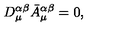

In [24]:
dataset[1]["image"]

In [20]:
with torch.inference_mode():
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
        use_cache=True,
    )
input_length = inputs["input_ids"].shape[1]

generated_ids = outputs[:, input_length:]

latex = tokenizer.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)[0].strip()

print(latex)

/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5317: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5317: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5317: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5317: UserWarning: 'has_mkldnn' is deprecated, please use 'torch.backends.mkldnn.is_available()'
  return original(name)


\frac { N } { M } \in { \bf Z } , \frac { M } { P } \in { \bf Z } , \frac { P } { Q } \in { \bf Z }


In [13]:
!pip install -q latex2sympy2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.8/89.8 kB 9.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omegaconf 2.3.1 requires antlr4-python3-runtime==4.9.*, but you have antlr4-python3-runtime 4.7.2 which is incompatible.


In [21]:
from IPython.display import display, Math

display(Math(latex))

<IPython.core.display.Math object>

ACTUAL:
D _ { \mu } ^ { \alpha \beta } \bar { A } _ { \mu } ^ { \alpha \beta } = 0 ,

GENERATED:
D _ { \mu } ^ { \alpha \beta } \bar { A } _ { \mu } ^ { \alpha \beta } = 0 ,

GENERATED RENDER:


<IPython.core.display.Math object>


ORIGINAL IMAGE:


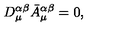

In [28]:
from IPython.display import display, Math

# Pick sample
idx = 1

image = dataset[idx]["image"]
actual_latex = dataset[idx]["text"]

# --------------------------------------------------
# Prepare prompt
# --------------------------------------------------

input_text = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
)

inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

# --------------------------------------------------
# Generate
# --------------------------------------------------

with torch.inference_mode():
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
        use_cache=True,
    )

# --------------------------------------------------
# Decode generated tokens only
# --------------------------------------------------

input_length = inputs["input_ids"].shape[1]

generated_ids = outputs[:, input_length:]

latex = tokenizer.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)[0].strip()

# --------------------------------------------------
# Print comparison
# --------------------------------------------------

print("=" * 80)
print("ACTUAL:")
print(actual_latex)

print("\nGENERATED:")
print(latex)

print("=" * 80)

# --------------------------------------------------
# Render prediction
# --------------------------------------------------

print("\nGENERATED RENDER:")
try:
    display(Math(latex))
except Exception as e:
    print("Rendering failed:", e)

# --------------------------------------------------
# Show original image
# --------------------------------------------------

print("\nORIGINAL IMAGE:")
display(image)

ACTUAL:
{ \ln } J _ { \theta } = { \frac { 1 } { 3 c { \cal A } } } \int _ { \theta } ^ { 1 } d \theta ^ { \prime } a _ { 5 / 2 } ( \phi , P _ { \theta ^ { \prime } } ) ,

GENERATED:
\ln J _ { \theta } = \frac { 1 } { 3 c { \cal A } } \int _ { \theta } ^ { 1 } d \theta ^ { \prime } \alpha _ { 5 / 2 } ( \phi , P _ { \theta ^ { \prime } } ) ,

GENERATED RENDER:


<IPython.core.display.Math object>


ORIGINAL IMAGE:


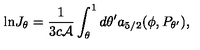

In [29]:
from IPython.display import display, Math

# Pick sample
idx = 15

image = dataset[idx]["image"]
actual_latex = dataset[idx]["text"]

# --------------------------------------------------
# Prepare prompt
# --------------------------------------------------

input_text = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
)

inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

# --------------------------------------------------
# Generate
# --------------------------------------------------

with torch.inference_mode():
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
        use_cache=True,
    )

# --------------------------------------------------
# Decode generated tokens only
# --------------------------------------------------

input_length = inputs["input_ids"].shape[1]

generated_ids = outputs[:, input_length:]

latex = tokenizer.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)[0].strip()

# --------------------------------------------------
# Print comparison
# --------------------------------------------------

print("=" * 80)
print("ACTUAL:")
print(actual_latex)

print("\nGENERATED:")
print(latex)

print("=" * 80)

# --------------------------------------------------
# Render prediction
# --------------------------------------------------

print("\nGENERATED RENDER:")
try:
    display(Math(latex))
except Exception as e:
    print("Rendering failed:", e)

# --------------------------------------------------
# Show original image
# --------------------------------------------------

print("\nORIGINAL IMAGE:")
display(image)